In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/planilha/base_credito.csv')

df.head()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


## Etapa 2 - Conhecendo os dados:







In [28]:
print(df.dtypes)
df.describe()

idade                     int64
renda_mensal            float64
score_credito             int64
historico_pagamentos    float64
valor_emprestimo        float64
dtype: object


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


Variáveis a serem utilizadas:

1.   idade: Idade do cliente, em anos
2.   renda_mensal: renda mensal do cliente, em reais
3.   score_credito: pontuação de crédito do cliente
4.   historico_pagamentos: percentual de pagamentos feitos em dia pelo cliente

Variável a ser prevista:

valor_emprestimo: valor do empréstimo concedido ao cliente, em reais.


## Etapa 3 - Analisar os dados

valor_emprestimo        1.000000
renda_mensal            0.886813
score_credito           0.358151
historico_pagamentos    0.076832
idade                   0.040998
Name: valor_emprestimo, dtype: float64


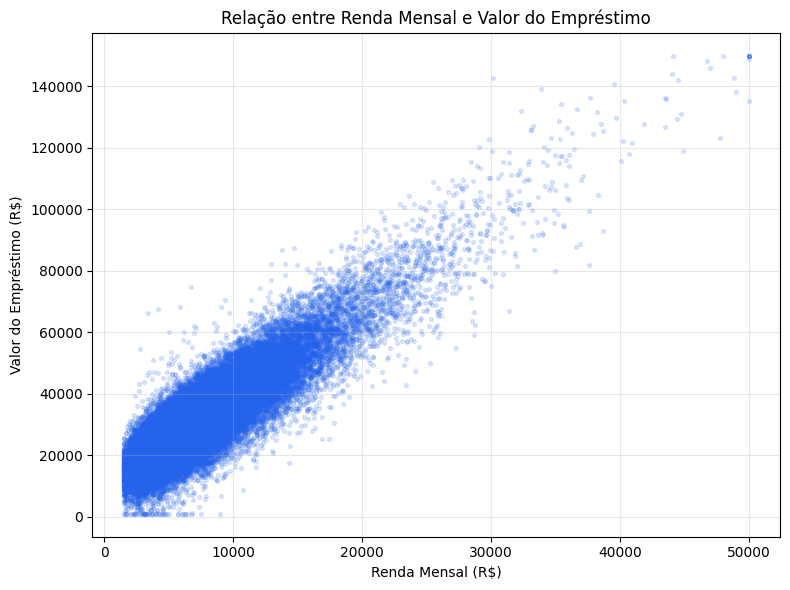

In [20]:
print(df.corr()['valor_emprestimo'].sort_values(ascending=False))

plt.figure(figsize=(8,6))
plt.scatter(df['renda_mensal'], df['valor_emprestimo'], alpha=0.15, s=8, color='#2563eb')
plt.xlabel('Renda Mensal (R$)')
plt.ylabel('Valor do Empréstimo (R$)')
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Pelos dados apresentados no gráfico,pode-se observar  uma relação maior entre a Renda mensal e o Valor do empréstimo. Porém, embora a correlação forte, outros fatores também influenciam, não gerando uma reta perfeita

## Etapa 4 - Preparando os dados

In [22]:
#definir variáveis de entrada e variável alvo

X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = df['valor_emprestimo']


#dividir o que será para treino e o que será para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(df):.0%})')
print(f'Tamanho do conjunto de teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(df):.0%})')


Tamanho do conjunto de treino: 40000 amostras (80%)
Tamanho do conjunto de teste:  10000 amostras (20%)


Nesses conjuntos foi utilizada uma proporção de 80% para treino e 20% para testes, o que é uma proporção recomendad em problemas que envolvem a regressão linear.

## Etapa 5 - Treinar o modelo

In [29]:
modelo = LinearRegression()

#treinar modelo
modelo.fit(X_train,y_train)

#gerar previsões
y_pred = modelo.predict(X_test)


print('Coeficientes:', {col: np.round(coef, 2) for col, coef in zip(X.columns, modelo.coef_)})
print('Intercepto:', np.round(modelo.intercept_, 2))


#comparando previsões com os valores reais
print('Previsões:', np.round(y_pred[:5], 2))
print('Valores reais:', np.round(y_test.values[:5], 2))

Coeficientes: {'idade': np.float64(54.71), 'renda_mensal': np.float64(2.83), 'score_credito': np.float64(60.89), 'historico_pagamentos': np.float64(98.91)}
Intercepto: -39439.69
Previsões: [14806.34 29512.49 25840.74 21077.52 27919.31]
Valores reais: [22268.46 27457.59 25451.04 23890.67 27754.95]


Usando a função LinearRegression do sklearn.linear_model, podemos criar um modelo de regressão linear que vai receber os dados.

Após isso usamos a função .fit(X_train, y_train) para realizar o treinamento. Ela vai receber o X_train e o Y_train e calcular os coeficientes que melhor ajustam a  reta como os dados.

Após isso usamos a função .predict(X_test) para aplicar a equação com os novos dados de teste.

## Etapa 6 - Avaliar modelo

In [32]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')

MAE: 2985.94
MSE: 16113542.06


MAE = Erro Absoluto Médio - 2.985,94

*   Representa a média da diferença absoluta entre os valores previtos e os valores reais. Ou seja, o modelo tem uma margem de erro de R$ 2.986 para cima ou para baixo em relação aos valores reais de empréstimos.

MSE = Erro Quadrátrico Médio - 16.113.542,06

*   Representa o erro quadrático médio, ou seja, a média das diferenças entre valor previsto e valor real elevadas ao quadrado. Esse valor mostra que, embora a maioria das previsões esteja próxima do valor real (como indica o MAE baixo), existem alguns casos com erro maior que impactam essa métrica.







## Etapa 7 - Comparar valores reais e previstos

In [34]:
comparacao = pd.DataFrame({
    'Valor Real': y_test.values,
    'Valor Previsto': y_pred,
})


comparacao['Diferença'] = comparacao['Valor Real'] - comparacao['Valor Previsto']
comparacao['Erro %'] = (comparacao['Diferença'].abs() / comparacao['Valor Real']) * 100

comparacao.head(10).round(2)

,Valor Real,Valor Previsto,Diferença,Erro %
0,22268.46,14806.34,7462.12,33.51
1,27457.59,29512.49,-2054.90,7.48
2,25451.04,25840.74,-389.70,1.53
3,23890.67,21077.52,2813.15,11.78
4,27754.95,27919.31,-164.36,0.59
5,12544.92,14530.91,-1985.99,15.83
6,28759.01,27385.97,1373.04,4.77
7,46454.49,41011.61,5442.88,11.72
8,43199.01,36525.09,6673.92,15.45
9,34051.39,35786.96,-1735.57,5.10


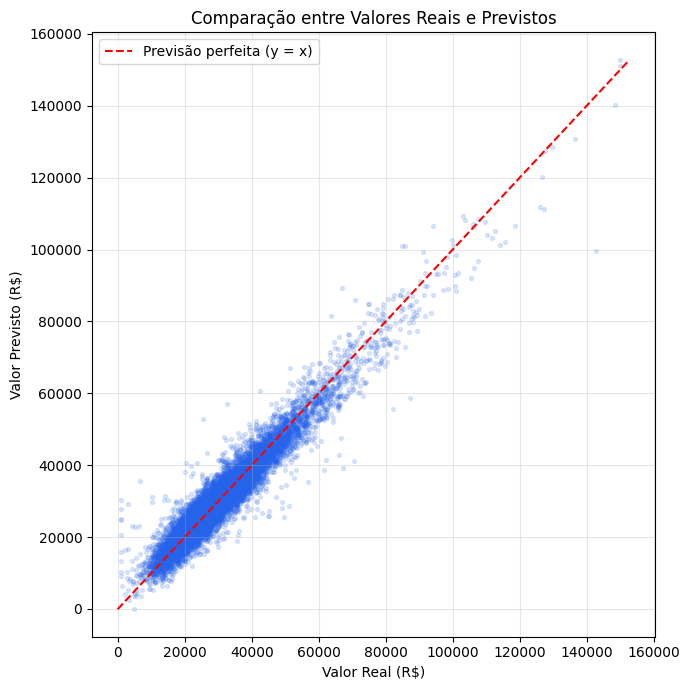

In [39]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.15, s=8, color='#2563eb')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Previsão perfeita (y = x)')

plt.xlabel('Valor Real (R$)')
plt.ylabel('Valor Previsto (R$)')
plt.title('Comparação entre Valores Reais e Previstos')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As previsões do modelo estão próximas dos valores reais, concentrados ao redor da linha de previsão. Ainda assim, existe uma margem de erro que pode ser relevante dependendo da aplicação.

## Etapa 8 - Fazer uma nova previsão



In [40]:
cliente_morya = pd.DataFrame({
    'idade': [37],
    'renda_mensal': [12000.00],
    'score_credito': [680],
    'historico_pagamentos': [88.5]
})


previsao = modelo.predict(cliente_morya)
print(f'Valor previsto do empréstimo: R$ {previsao[0]:.2f}')

Valor previsto do empréstimo: R$ 46684.69


O cliente possui uma renda mensal acima da média, que é de R$ 7.542, o que agrega no valor do empréstimo. Além disso, seu score e histórico de pagamentos possuem  bons valores, o que reforça um perfill com baixo risco.

O valor do empréstimo(R$46.684,69) ficou acima da média geral de empréstimos da base (R$ 31.736), o que é coerente com o perfil financeiro. Assim, um cliente com boa renda, bom score e bom histórico tende mesmo a receber ofertas de crédito maiores.



## Etapa 9 - Conclusão

O modelo, no fim, apresentou resultados adequados para a estimativa de valores e empréstimo.

O resultado do MAE apresenta um erro médio relativamente baixo. Na comparação dos valores na etapa 7, nota-se que a maioria das previsões se aproximava da linha de previsão perfeita e o teste com um novo cliente gerou uma previsão coerente com o perfil financeiro apresentado.

Já em relação as limitações, podemos citar algumas, como por exemplo:

1.   A quantidade de variáveis disponíveis é relativamente pequena, utilizando apenas 4. Para modelos maiores de fintechs, uma quantidade maior de variáveis pode ser utilizado, como emprego do cliente, patrimônio, dividas atuais, etc.
2.   Modelo linear pode não capturar relações mais complexas, pois podem existir padrões não lineares entre variáveis e outras interações entre variáveis que devam ser analisadas, necessitando um modelo mais complexo de para melhor capturar esses padrões
3.  Ausência de validação mais robusta. Foi usada apenas uma divisão simples entre treino e teste (80/20). Técnicas mais robustas, poderiam dar uma estimativa mais confiável do desempenho real do modelo em dados novos.

